In [1]:
import pandas as pd

# Load airline passengers dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

df = pd.read_csv(url)

print(df.head())


     Month  Passengers
0  1949-01         112
1  1949-02         118
2  1949-03         132
3  1949-04         129
4  1949-05         121


In [2]:
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

print(df.head())


            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


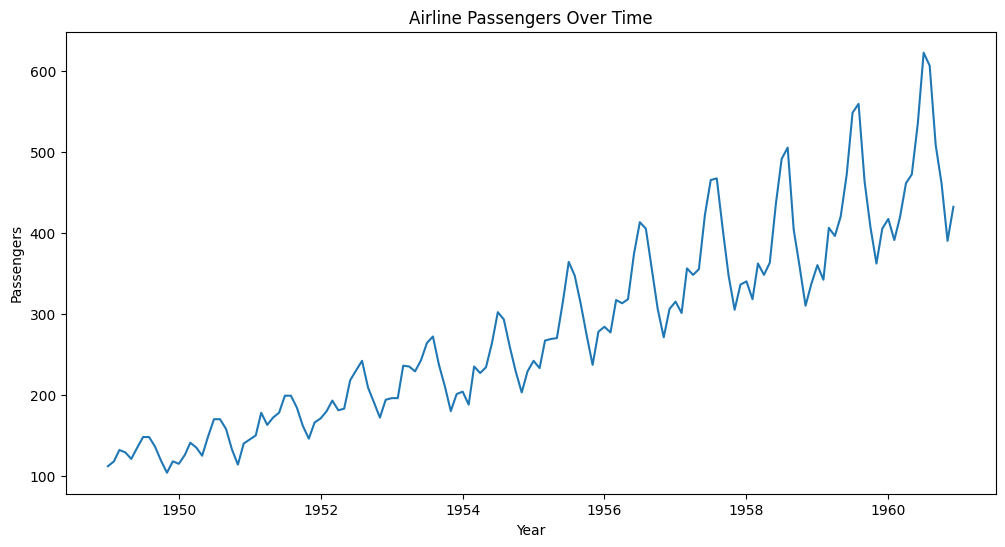

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(df['Passengers'])
plt.title("Airline Passengers Over Time")
plt.xlabel("Year")
plt.ylabel("Passengers")
plt.show()


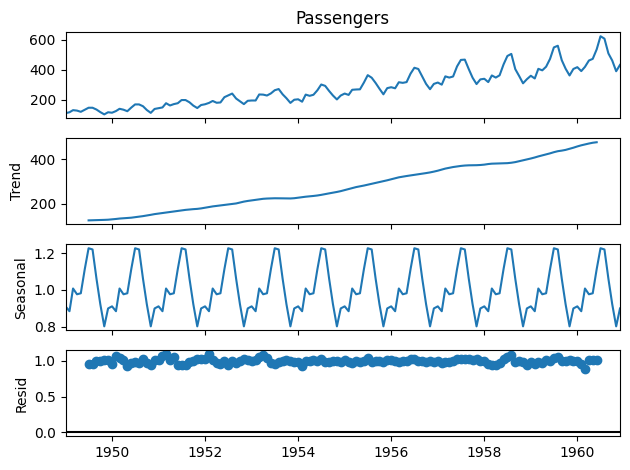

In [4]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(df['Passengers'], model='multiplicative')

decomposition.plot()
plt.show()


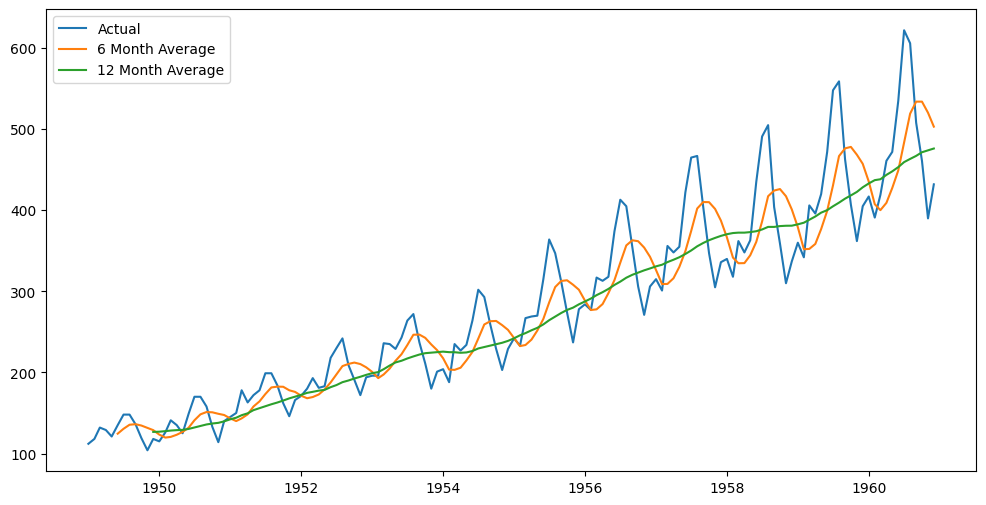

In [5]:
df['MA_6'] = df['Passengers'].rolling(window=6).mean()
df['MA_12'] = df['Passengers'].rolling(window=12).mean()

plt.figure(figsize=(12,6))
plt.plot(df['Passengers'], label='Actual')
plt.plot(df['MA_6'], label='6 Month Average')
plt.plot(df['MA_12'], label='12 Month Average')
plt.legend()
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


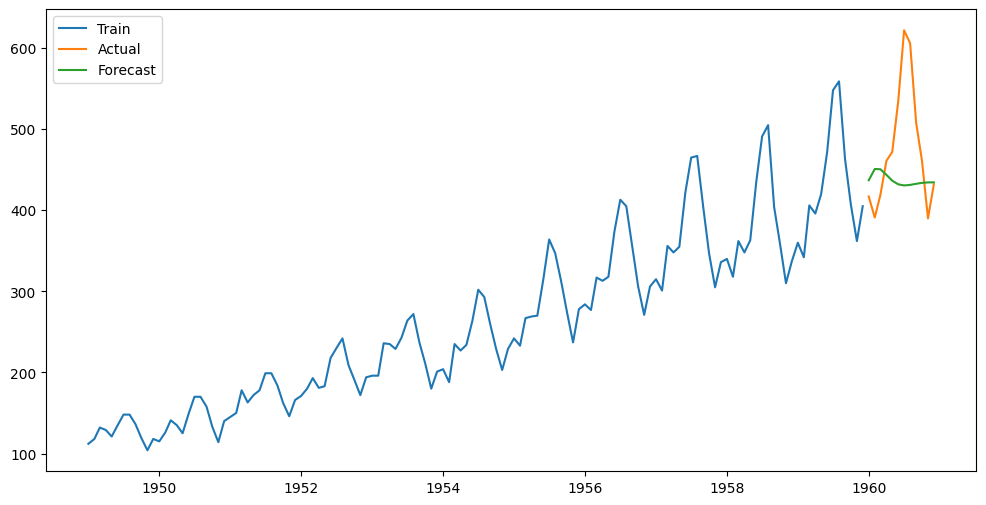

In [6]:
from statsmodels.tsa.arima.model import ARIMA

# Split data
train = df.iloc[:-12]
test = df.iloc[-12:]

# Train model
model = ARIMA(train['Passengers'], order=(2,1,1))
model_fit = model.fit()

# Forecast
forecast = model_fit.forecast(steps=12)

# Plot forecast
plt.figure(figsize=(12,6))
plt.plot(train.index, train['Passengers'], label="Train")
plt.plot(test.index, test['Passengers'], label="Actual")
plt.plot(test.index, forecast, label="Forecast")
plt.legend()
plt.show()


In [7]:
df.to_csv("airline_passengers_cleaned.csv")


In [8]:
from google.colab import files
files.download("airline_passengers_cleaned.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>